In [5]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("Reviews .csv")
df

,category,rating,label,text_
0,Home_and_Kitchen_5,5.0,CG,"Love this! Well made, sturdy, and very comfor..."
1,Home_and_Kitchen_5,5.0,CG,"love it, a great upgrade from the original. I..."
2,Home_and_Kitchen_5,5.0,CG,This pillow saved my back. I love the look and...
3,Home_and_Kitchen_5,1.0,CG,"Missing information on how to use it, but it i..."
4,Home_and_Kitchen_5,5.0,CG,Very nice set. Good quality. We have had the s...
...,...,...,...,...
40427,Clothing_Shoes_and_Jewelry_5,4.0,OR,I had read some reviews saying that this bra r...
40428,Clothing_Shoes_and_Jewelry_5,5.0,CG,I wasn't sure exactly what it would be. It is ...
40429,Clothing_Shoes_and_Jewelry_5,2.0,OR,"You can wear the hood by itself, wear it with ..."
40430,Clothing_Shoes_and_Jewelry_5,1.0,CG,I liked nothing about this dress. The only rea...


In [6]:
df.isnull().sum()

category    0
rating      0
label       0
text_       0
dtype: int64

In [7]:
df['label'].value_counts()

label
CG    20216
OR    20216
Name: count, dtype: int64

In [18]:
print("Fake review example :")
print(df[df["label"]=="CG"]["text_"].iloc[0])


Fake review example :
Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty


In [24]:
import re

def clean_text(text):
    text = text.lower()
    
    # remove punctuation & symbols
    text = re.sub(r'[^a-z\s]', '', text)
    
    # remove extra spaces (keep ONE space)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text

df["clean_text"]=df["text_"].apply(clean_text)

In [25]:
print("BEFORE:\n", df["text_"].iloc[0])
print("\nAFTER:\n", df["clean_text"].iloc[0])


BEFORE:
 Love this!  Well made, sturdy, and very comfortable.  I love it!Very pretty

AFTER:
 love this well made sturdy and very comfortable i love itvery pretty


In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf =TfidfVectorizer(
    max_features=5000,
    stop_words= 'english'
)




In [30]:
X= tfidf.fit_transform(df["clean_text"])
X.shape


(40432, 5000)

In [35]:
df["label_num"]=df["label"].map({
    "CG":1,
    "OR":0
})

y= df["label_num"]


0        1
1        1
2        1
3        1
4        1
        ..
40427    0
40428    1
40429    0
40430    1
40431    0
Name: label_num, Length: 40432, dtype: int64 1


In [36]:
from sklearn.model_selection import train_test_split 

X_train, X_test, y_train , y_test = train_test_split(X,y, test_size=0.2, random_state=42)



In [38]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train,y_train)

LogisticRegression()

In [39]:
y_pred=model.predict(X_test)

In [40]:
from sklearn.metrics import classification_report 

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.87      0.86      4071
           1       0.87      0.85      0.86      4016

    accuracy                           0.86      8087
   macro avg       0.86      0.86      0.86      8087
weighted avg       0.86      0.86      0.86      8087



In [41]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)



[[3559  512]
 [ 606 3410]]


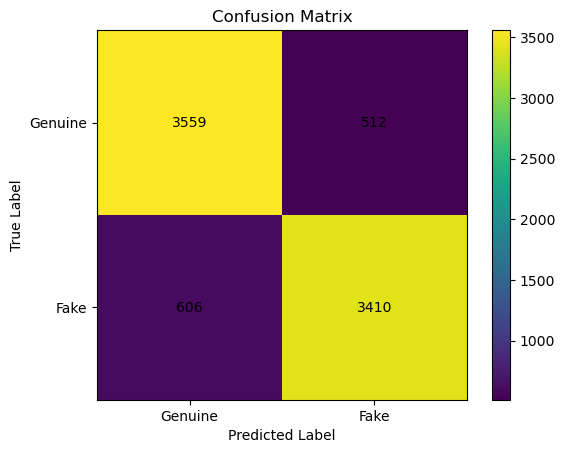

In [44]:
plt.figure()
plt.imshow(cm)
plt.colorbar()

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks([0, 1], ["Genuine", "Fake"])
plt.yticks([0, 1], ["Genuine", "Fake"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.show()


In [51]:
def detect_review(review_text):

    cleaned_text = clean_text(review_text)

    vector = tfidf.transform(cleaned_text)

    prediction=model.predict(vector)

    if prediction[0] == 1 :
        return "fake review "
    else :
        return "Genuine review "


